In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import xticks, yticks
from sklearn.datasets import load_digits
from sklearn.cluster import KMeans

digits = load_digits()

Matplotlib is building the font cache; this may take a moment.


In [2]:
digits.data.shape

(1797, 64)

In [3]:
digits.target.shape

(1797,)

In [4]:
clf = KMeans(n_clusters=10, verbose=3, random_state=0)

In [5]:
clusters = clf.fit_predict(digits.data)

Initialization complete
Iteration 0, inertia 1883216.0.
Iteration 1, inertia 1213908.6169769217.
Iteration 2, inertia 1197396.2403531037.
Iteration 3, inertia 1190134.7879864173.
Iteration 4, inertia 1184659.211113247.
Iteration 5, inertia 1182293.3096599807.
Iteration 6, inertia 1181306.468904349.
Iteration 7, inertia 1180608.628757222.
Iteration 8, inertia 1180078.0193842635.
Iteration 9, inertia 1179467.5178881742.
Iteration 10, inertia 1178028.9382105924.
Iteration 11, inertia 1175180.939821948.
Iteration 12, inertia 1173115.396449361.
Iteration 13, inertia 1172172.602442375.
Iteration 14, inertia 1171676.454299934.
Iteration 15, inertia 1171454.0449607177.
Iteration 16, inertia 1171372.9194104662.
Iteration 17, inertia 1171302.3768490476.
Iteration 18, inertia 1171289.220491156.
Converged at iteration 18: strict convergence.


In [6]:
clf.cluster_centers_.shape

(10, 64)

In [7]:
c = clf.cluster_centers_.reshape(10, 8, 8)

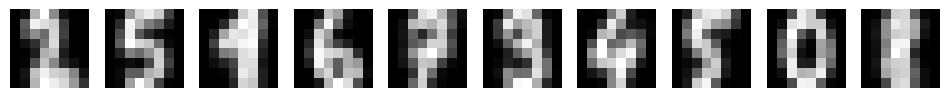

In [13]:
_, axes = plt.subplots(nrows=1, ncols=10, figsize=(12, 4))
for ax, image in zip(axes.flat, c):
    ax.set_axis_off()
    # ax.title(label)
    ax.imshow(image, interpolation="nearest", cmap="gray")

In [9]:
from scipy.stats import mode

labels = np.zeros_like(clusters)
for i in range(10):
    mask = clusters == i
    labels[mask] = mode(digits.target[mask])[0]

In [10]:
labels

array([0, 8, 8, ..., 8, 3, 3], shape=(1797,), dtype=int32)

In [11]:
# todo redo
from sklearn import metrics

metrics.accuracy_score(digits.target, labels)

0.7440178074568725